# **Brain Tumour Detection and Classification from MRI Images Using Convolutional Neural Networks**

Dataset Link : https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

## **Dataset Downloading**

**Google Colab**

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"efficient8","key":"0e26061c5d5cf73b850e01f7c6575016"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 215MB/s]



In [7]:
!unzip -q brain-tumor-mri-dataset.zip

**Libraries**

In [8]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tensorflow as tf
import random
from PIL import Image
warnings.filterwarnings('ignore')

## **Image Data**

In [9]:
os.makedirs("data", exist_ok=True)
os.rename("Testing", "data/Testing")
os.rename("Training", "data/Training")

**Train Data Count**

In [10]:
train_dir = "data/Training"

list_of_directories = os.listdir(train_dir)

for dir in list_of_directories:
    dir_path = os.path.join(train_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    print(f"{dir} has {count_of_images} images")

meningioma has 1400 images
pituitary has 1400 images
notumor has 1400 images
glioma has 1400 images


**Test Data Count**

In [11]:
test_dir = "data/Testing"

list_of_directories = os.listdir(test_dir)

for dir in list_of_directories:
    dir_path = os.path.join(test_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    print(f"{dir} has {count_of_images} images")

meningioma has 400 images
pituitary has 400 images
notumor has 400 images
glioma has 400 images


**Test Data Creation**

In [12]:
train_dir = "data/Training"
val_dir = "data/Validation"

# Create validation directory if not exists
os.makedirs(val_dir, exist_ok=True)

for class_name in os.listdir(train_dir):

    class_train_path = os.path.join(train_dir, class_name)
    class_test_path = os.path.join(val_dir, class_name)

    # Skip if not directory
    if not os.path.isdir(class_train_path):
        continue

    os.makedirs(class_test_path, exist_ok=True)

    images = os.listdir(class_train_path)
    random.shuffle(images)

    # 10% split
    split_size = int(0.10 * len(images))
    val_images = images[:split_size]

    for img in val_images:
        src_path = os.path.join(class_train_path, img)
        dst_path = os.path.join(class_test_path, img)
        shutil.move(src_path, dst_path)

print("Validation data created")

Validation data created


In [13]:
train_list_of_directories = os.listdir(train_dir)

print("Train Data after Validation Data creation")
print("="*25)
for dir in train_list_of_directories:
    dir_path = os.path.join(train_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    print(f"{dir} has {count_of_images} images")


print("\nTest Data Count")
print("="*25)
test_list_of_directories = os.listdir(test_dir)

for dir in test_list_of_directories:
    dir_path = os.path.join(test_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    print(f"{dir} has {count_of_images} images")

print("\nValidation Data Count")
print("="*25)
val_list_of_directories = os.listdir(val_dir)

for dir in val_list_of_directories:
    dir_path = os.path.join(val_dir, dir)
    count_of_images = len(os.listdir(dir_path))
    print(f"{dir} has {count_of_images} images")

Train Data after Validation Data creation
meningioma has 1260 images
pituitary has 1260 images
notumor has 1260 images
glioma has 1260 images

Test Data Count
meningioma has 400 images
pituitary has 400 images
notumor has 400 images
glioma has 400 images

Validation Data Count
meningioma has 140 images
pituitary has 140 images
notumor has 140 images
glioma has 140 images


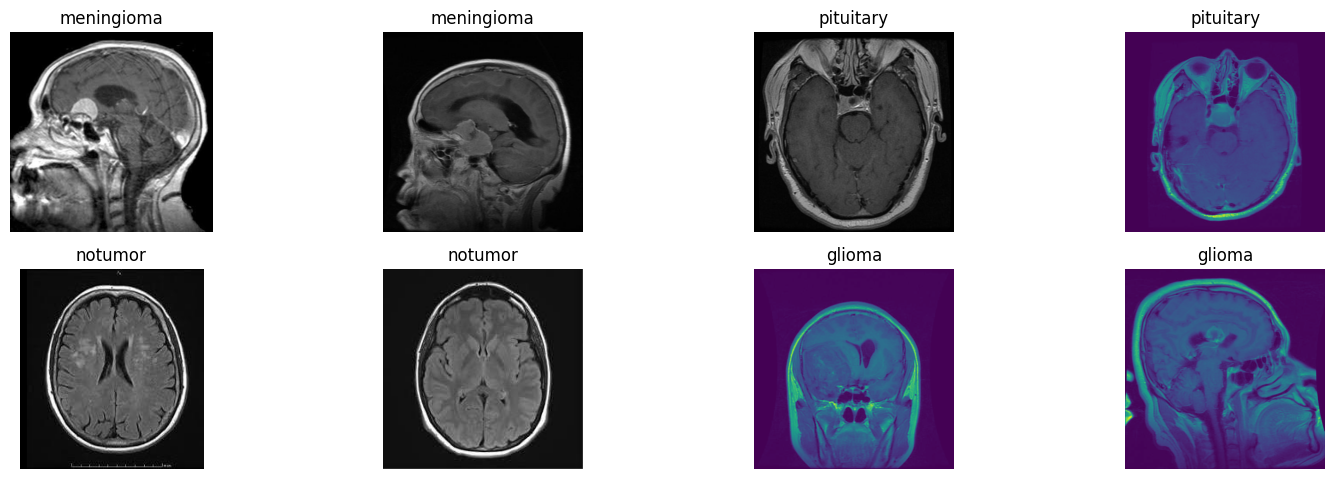

In [14]:
classes = os.listdir(train_dir)

rows = 5
cols = 4
max_images = rows * cols   # 20

plt.figure(figsize=(15, 12))

plot_index = 1

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)

    images = random.sample(os.listdir(class_path), 2)

    for img_name in images:
        if plot_index > max_images:
            break

        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(rows, cols, plot_index)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

        plot_index += 1

    if plot_index > max_images:
        break

plt.tight_layout()
plt.show()

## **Data Augmentation**

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [16]:
img_size = (224, 224)
batch_size = 32

In [17]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 5040 images belonging to 4 classes.


In [18]:
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 560 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


## **Model Building**

In [19]:
from collections import Counter

# Get class labels
class_labels = train_generator.class_indices
print("Class Labels:", class_labels)

# Count samples
counts = Counter(train_generator.classes)

# Imbalance Ratio
counts_list = np.array(list(counts.values()))

imbalance_ratio = counts_list.max() / counts_list.min()
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")

Class Labels: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Imbalance Ratio: 1.00


In [20]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights)


Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


In [21]:
class_len = train_generator.num_classes
epochs = 10
model_metrics = []

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks = [early_stop]

In [23]:
def evaluate_model(model, name, generator):
    print(f"\nEvaluating {name}...")
    results = model.evaluate(generator, verbose=0)
    metrics = {
        'Model': name,
        'Loss': results[0],
        'Accuracy': results[1],
        'Precision': results[2],
        'Recall': results[3],
        'F1-Score': results[4]
    }
    return metrics

In [26]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.applications import ResNet50, DenseNet121
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import label_binarize
import cv2
import random

#### **CNN**

In [27]:
cnn_model = Sequential([
    Input(shape=(224, 224, 3)),

    # First block
    Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Second block
    Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Third block
    Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Fourth block
    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.5),

    # Classifier
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(class_len, activation='softmax')
])

In [28]:
cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001, decay=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [29]:
cnn_history = cnn_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, class_weight=class_weights, callbacks=callbacks)

Epoch 1/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 132s 612ms/step - accuracy: 0.5740 - f1_score: 0.5723 - loss: 1.1746 - precision: 0.6141 - recall: 0.5264 - val_accuracy: 0.2500 - val_f1_score: 0.1000 - val_loss: 5.4121 - val_precision: 0.2500 - val_recall: 0.2500
Epoch 2/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 71s 449ms/step - accuracy: 0.6677 - f1_score: 0.6650 - loss: 0.9010 - precision: 0.7047 - recall: 0.6268 - val_accuracy: 0.4125 - val_f1_score: 0.2925 - val_loss: 3.0898 - val_precision: 0.4149 - val_recall: 0.4089
Epoch 3/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 76s 478ms/step - accuracy: 0.7159 - f1_score: 0.7135 - loss: 0.7577 - precision: 0.7451 - recall: 0.6744 - val_accuracy: 0.3946 - val_f1_score: 0.3393 - val_loss: 2.2456 - val_precision: 0.3946 - val_recall: 0.3643
Epoch 4/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 73s 459ms/step - accuracy: 0.7296 - f1_score: 0.7276 - loss: 0.6923 - precision: 0.7593 - recall: 0.6946 - val_accuracy: 0.5607 - val_f1_score: 0.5114 - val_loss: 1.5200 - val_precision: 0.5797 

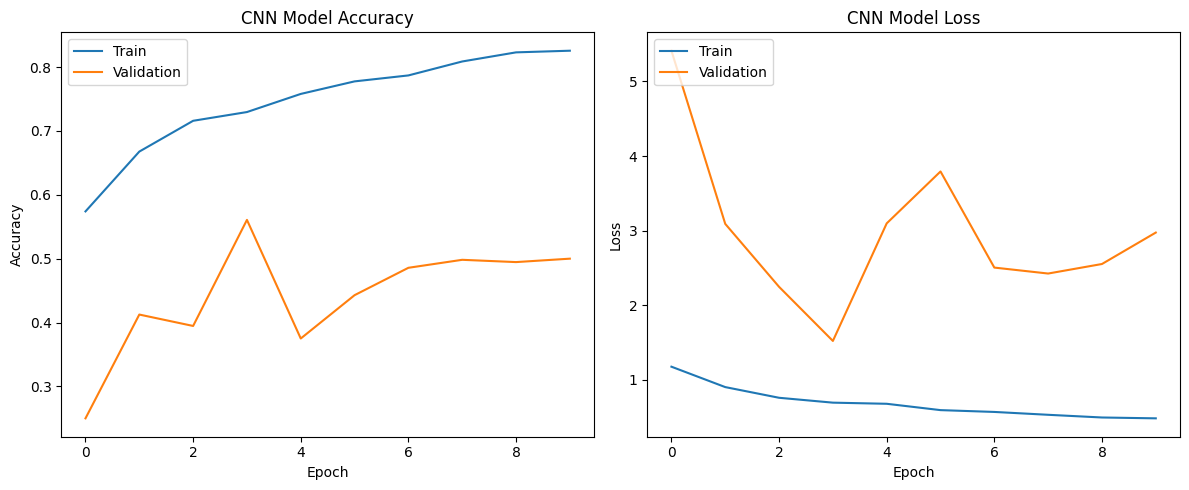

In [30]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])
plt.title('CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.title('CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [31]:
cnn_metrics = evaluate_model(cnn_model, 'CNN', val_generator)
model_metrics.append(cnn_metrics)


Evaluating CNN...


In [32]:
model_metrics

[{'Model': 'CNN',
  'Loss': 1.5199984312057495,
  'Accuracy': 0.5607143044471741,
  'Precision': 0.5796545147895813,
  'Recall': 0.5392857193946838,
  'F1-Score': 0.511380672454834}]

#### **ResNet50**

In [33]:
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_resnet.trainable = False

x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(class_len, activation='softmax')(x)

resnet_model = Model(inputs=base_resnet.input, outputs=output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [34]:
resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001, decay=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [35]:
resnet_history = resnet_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, class_weight=class_weights, callbacks=callbacks)

Epoch 1/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 93s 506ms/step - accuracy: 0.4157 - f1_score: 0.4244 - loss: 1.2879 - precision: 0.9582 - recall: 0.0546 - val_accuracy: 0.4321 - val_f1_score: 0.3239 - val_loss: 1.1713 - val_precision: 0.9467 - val_recall: 0.1268
Epoch 2/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 68s 430ms/step - accuracy: 0.4702 - f1_score: 0.4805 - loss: 1.1739 - precision: 0.9550 - recall: 0.1179 - val_accuracy: 0.4607 - val_f1_score: 0.3639 - val_loss: 1.1078 - val_precision: 0.9247 - val_recall: 0.1536
Epoch 3/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 81s 423ms/step - accuracy: 0.5345 - f1_score: 0.5411 - loss: 1.1278 - precision: 0.9441 - recall: 0.1308 - val_accuracy: 0.6143 - val_f1_score: 0.6124 - val_loss: 1.0597 - val_precision: 0.9307 - val_recall: 0.1679
Epoch 4/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 67s 427ms/step - accuracy: 0.5369 - f1_score: 0.5441 - loss: 1.0918 - precision: 0.9316 - recall: 0.1486 - val_accuracy: 0.6500 - val_f1_score: 0.6431 - val_loss: 1.0274 - val_precision: 0.9300 -

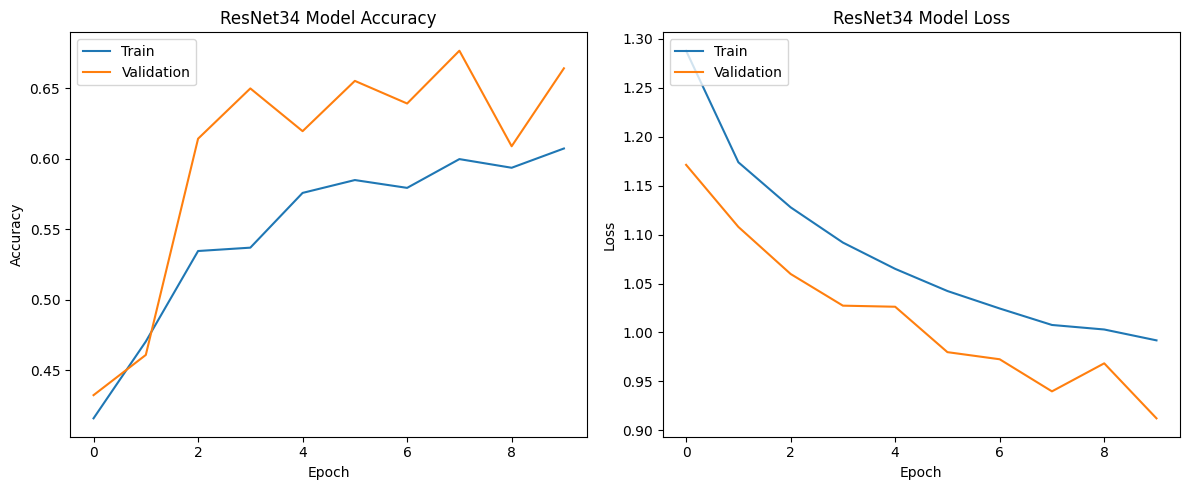

In [36]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(resnet_history.history['accuracy'])
plt.plot(resnet_history.history['val_accuracy'])
plt.title('ResNet34 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(resnet_history.history['loss'])
plt.plot(resnet_history.history['val_loss'])
plt.title('ResNet34 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [37]:
resnet_metrics = evaluate_model(resnet_model, 'ResNet34', val_generator)
model_metrics.append(resnet_metrics)


Evaluating ResNet34...


In [38]:
model_metrics

[{'Model': 'CNN',
  'Loss': 1.5199984312057495,
  'Accuracy': 0.5607143044471741,
  'Precision': 0.5796545147895813,
  'Recall': 0.5392857193946838,
  'F1-Score': 0.511380672454834},
 {'Model': 'ResNet34',
  'Loss': 0.9122349619865417,
  'Accuracy': 0.6642857193946838,
  'Precision': 0.8625592589378357,
  'Recall': 0.32499998807907104,
  'F1-Score': 0.6551967263221741}]

#### **DenseNet121**

In [39]:
# Load DenseNet121 base model
base_model_densenet = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze some layers for fine-tuning
for layer in base_model_densenet.layers[:300]: # Freeze first 300 layers
    layer.trainable = False
for layer in base_model_densenet.layers[300:]:
    layer.trainable = True

# Build custom classification layers on top of DenseNet121
x = base_model_densenet.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

densenet_model = Model(inputs=base_model_densenet.input, outputs=predictions)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [40]:
densenet_model.compile(
    optimizer=Adam(learning_rate=0.0001, decay=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall', F1Score(average='macro')]
)

In [41]:
densenet_history = densenet_model.fit(train_generator, epochs=epochs, verbose=1,
          validation_data=val_generator, class_weight=class_weights, callbacks=callbacks)

Epoch 1/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 203s 853ms/step - accuracy: 0.8093 - f1_score: 0.8086 - loss: 0.5366 - precision: 0.8305 - recall: 0.7921 - val_accuracy: 0.9125 - val_f1_score: 0.9116 - val_loss: 0.2634 - val_precision: 0.9173 - val_recall: 0.9107
Epoch 2/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 69s 437ms/step - accuracy: 0.9040 - f1_score: 0.9040 - loss: 0.2584 - precision: 0.9138 - recall: 0.8978 - val_accuracy: 0.9518 - val_f1_score: 0.9517 - val_loss: 0.1557 - val_precision: 0.9535 - val_recall: 0.9518
Epoch 3/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 70s 444ms/step - accuracy: 0.9341 - f1_score: 0.9342 - loss: 0.1909 - precision: 0.9387 - recall: 0.9298 - val_accuracy: 0.9482 - val_f1_score: 0.9478 - val_loss: 0.1748 - val_precision: 0.9479 - val_recall: 0.9429
Epoch 4/10
158/158 ━━━━━━━━━━━━━━━━━━━━ 70s 441ms/step - accuracy: 0.9506 - f1_score: 0.9506 - loss: 0.1474 - precision: 0.9542 - recall: 0.9468 - val_accuracy: 0.9571 - val_f1_score: 0.9569 - val_loss: 0.1539 - val_precision: 0.9589 

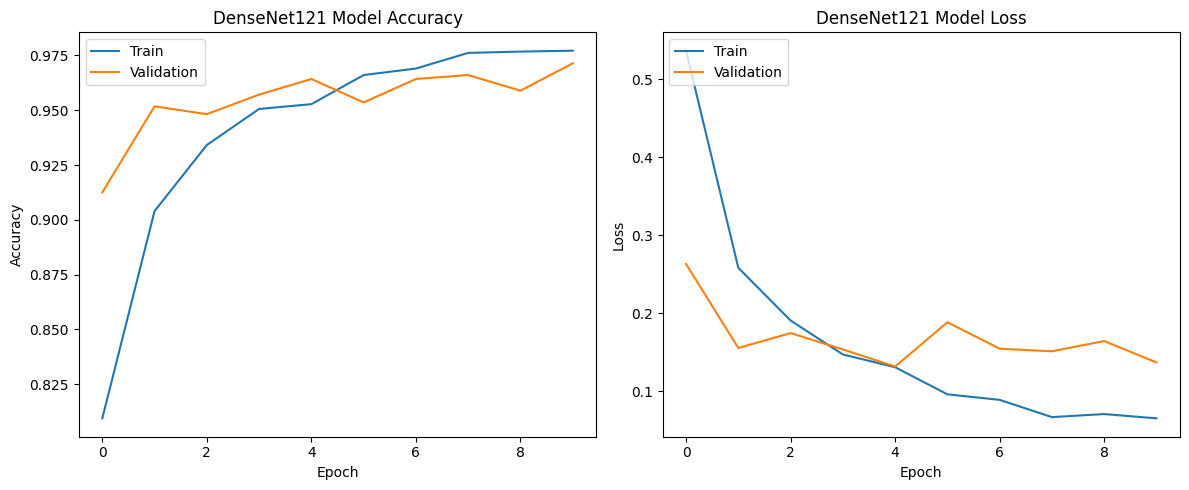

In [42]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(densenet_history.history['accuracy'])
plt.plot(densenet_history.history['val_accuracy'])
plt.title('DenseNet121 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(densenet_history.history['loss'])
plt.plot(densenet_history.history['val_loss'])
plt.title('DenseNet121 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [43]:
densenet_metrics = evaluate_model(densenet_model, 'DenseNet121', val_generator)
model_metrics.append(densenet_metrics)


Evaluating DenseNet121...


In [44]:
model_metrics

[{'Model': 'CNN',
  'Loss': 1.5199984312057495,
  'Accuracy': 0.5607143044471741,
  'Precision': 0.5796545147895813,
  'Recall': 0.5392857193946838,
  'F1-Score': 0.511380672454834},
 {'Model': 'ResNet34',
  'Loss': 0.9122349619865417,
  'Accuracy': 0.6642857193946838,
  'Precision': 0.8625592589378357,
  'Recall': 0.32499998807907104,
  'F1-Score': 0.6551967263221741},
 {'Model': 'DenseNet121',
  'Loss': 0.13184106349945068,
  'Accuracy': 0.9642857313156128,
  'Precision': 0.9642218351364136,
  'Recall': 0.9624999761581421,
  'F1-Score': 0.9638505578041077}]

## **Model Metrics Plot**

In [45]:
metrics_df = pd.DataFrame(model_metrics)
print("\nAll Model Evaluation Metrics:")
print(metrics_df)


All Model Evaluation Metrics:
         Model      Loss  Accuracy  Precision    Recall  F1-Score
0          CNN  1.519998  0.560714   0.579655  0.539286  0.511381
1     ResNet34  0.912235  0.664286   0.862559  0.325000  0.655197
2  DenseNet121  0.131841  0.964286   0.964222  0.962500  0.963851


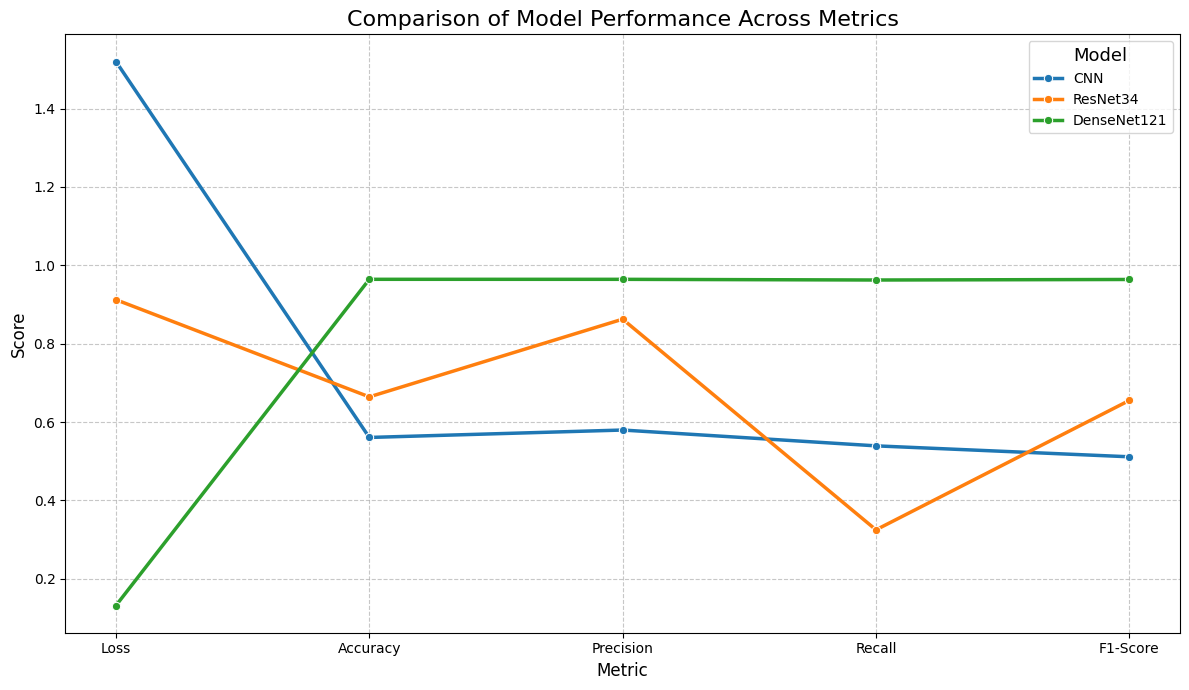

In [46]:
metrics_df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.lineplot(data=metrics_df_melted, x='Metric', y='Score', hue='Model', marker='o', linewidth=2.5)
plt.title('Comparison of Model Performance Across Metrics', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Model', title_fontsize='13', fontsize='10')
plt.tight_layout()
plt.show()

#### **Confusion Matrix**

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step


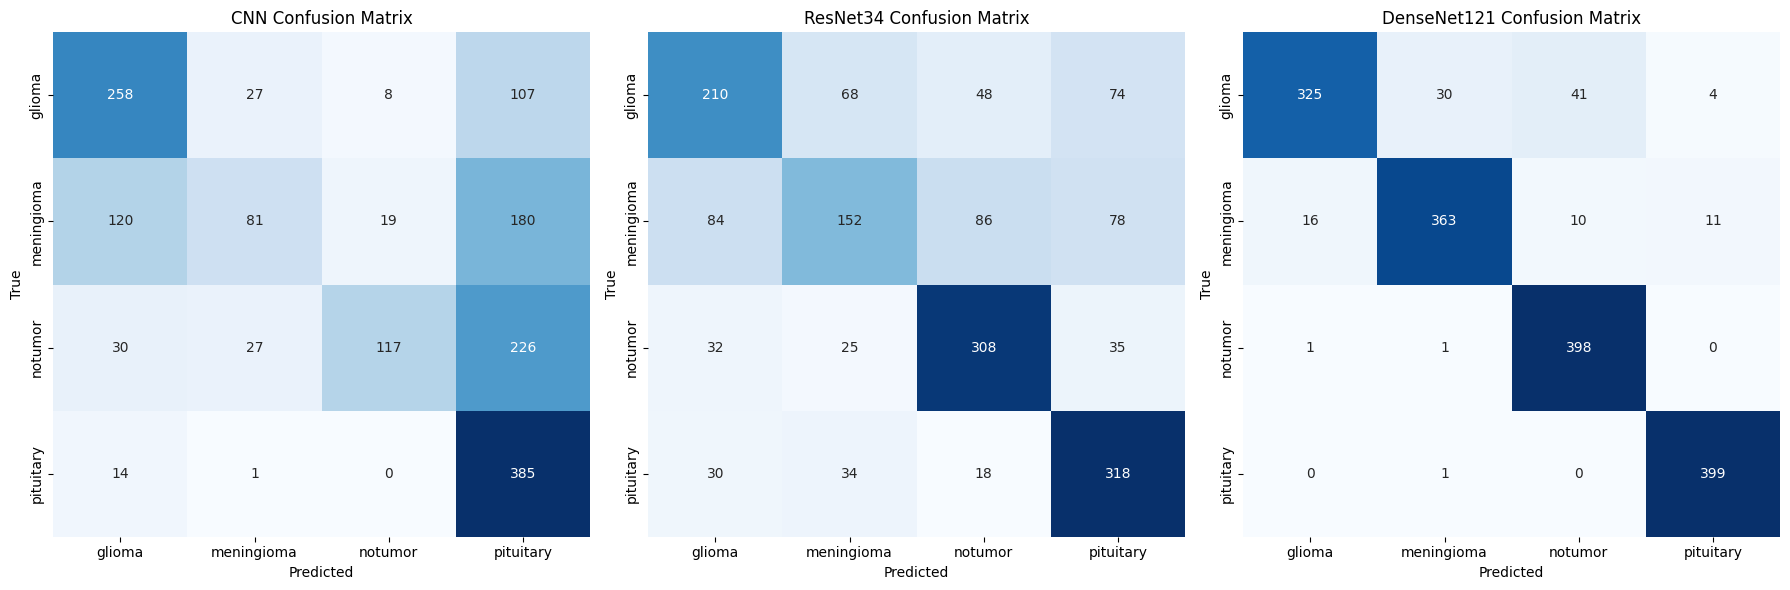

In [47]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_for_model(model, generator, title, ax):
    """
    Computes and plots the confusion matrix for a given model.
    """
    # Predict the classes for the test data
    y_pred = model.predict(generator)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Get the true labels in the order they were processed by the generator
    y_true = generator.classes[generator.index_array]

    # Get class names from generator
    class_names = list(generator.class_indices.keys())

    # Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred_classes)

    # Plot the confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

# Create a figure and a set of subplots in a 1x3 grid
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot confusion matrix for CNN model
plot_confusion_matrix_for_model(cnn_model, test_generator, 'CNN Confusion Matrix', axes[0])

# Plot confusion matrix for ResNet34 model
plot_confusion_matrix_for_model(resnet_model, test_generator, 'ResNet34 Confusion Matrix', axes[1])

# Plot confusion matrix for DenseNet121 model
plot_confusion_matrix_for_model(densenet_model, test_generator, 'DenseNet121 Confusion Matrix', axes[2])

plt.tight_layout()
plt.show()

## **ROC-AUC Curves**

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step


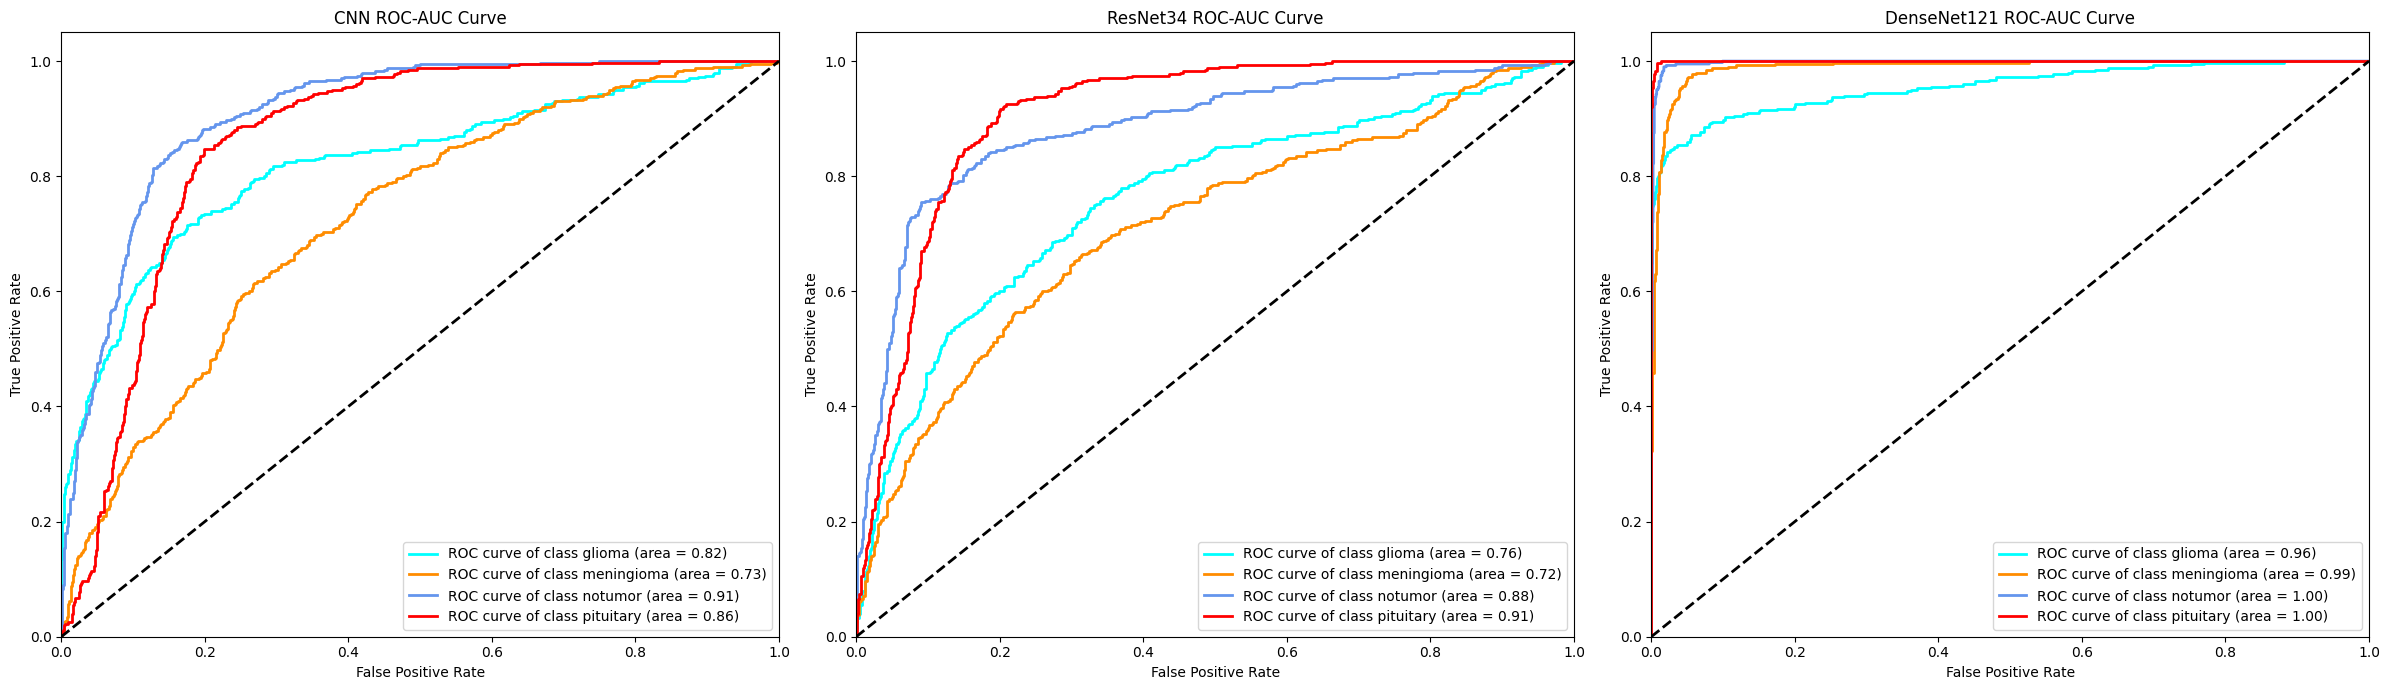

In [48]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

def plot_roc_curve_for_model(model, generator, title, ax):
    """
    Computes and plots the ROC-AUC curve for a given model.
    """
    y_pred_proba = model.predict(generator)
    y_true_labels = generator.classes[generator.index_array]

    n_classes = generator.num_classes
    class_names = list(generator.class_indices.keys())

    # Binarize the true labels
    y_true_binarized = label_binarize(y_true_labels, classes=np.arange(n_classes))

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red'])
    for i, color in zip(range(n_classes), colors):
        ax.plot(fpr[i], tpr[i], color=color, lw=2,
                label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]))

    ax.plot([0, 1], [0, 1], 'k--', lw=2)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend(loc='lower right')

# Create a figure and a set of subplots in a 1x3 grid
fig_roc, axes_roc = plt.subplots(1, 3, figsize=(24, 7))

# Plot ROC-AUC for CNN model
plot_roc_curve_for_model(cnn_model, test_generator, 'CNN ROC-AUC Curve', axes_roc[0])

# Plot ROC-AUC for ResNet34 model
plot_roc_curve_for_model(resnet_model, test_generator, 'ResNet34 ROC-AUC Curve', axes_roc[1])

# Plot ROC-AUC for DenseNet121 model
plot_roc_curve_for_model(densenet_model, test_generator, 'DenseNet121 ROC-AUC Curve', axes_roc[2])

plt.tight_layout()
plt.show()

## **Test Predictions**

In [50]:
best_model_row = metrics_df.loc[metrics_df['Accuracy'].idxmax()]
best_model_name = best_model_row['Model']

print(f"The best model based on F1-score is: {best_model_name}")

if best_model_name == 'CNN':
    best_model = cnn_model
elif best_model_name == 'ResNet34':
    best_model = resnet_model
elif best_model_name == 'DenseNet121':
    best_model = densenet_model
else:
    print(f"Warning: Best model '{best_model_name}' not recognized. Using CNN model as fallback.")
    best_model = cnn_model # Fallback if name not matched

The best model based on F1-score is: DenseNet121


In [51]:
# Get class names from the test_generator
class_indices = test_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

num_images_to_predict = 3

# Collect all image paths and their actual labels from the test directory
all_test_images = []
for class_name in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            all_test_images.append((os.path.join(class_path, img_name), class_name))



Performing predictions using the DenseNet121 model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


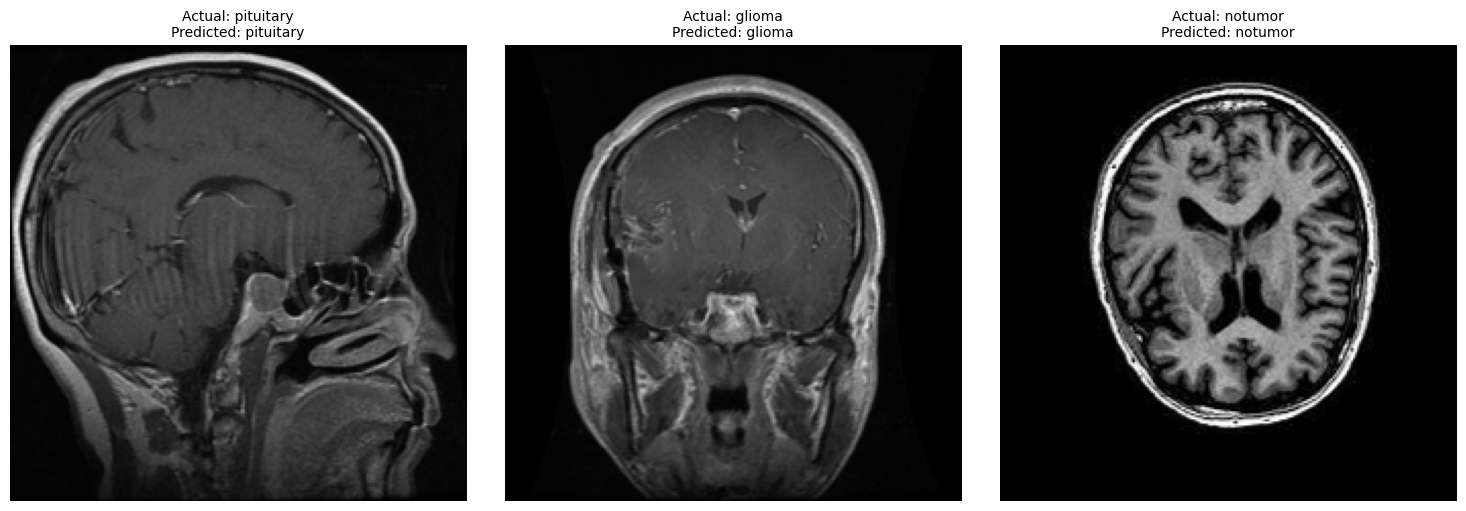

In [52]:
if len(all_test_images) < num_images_to_predict:
    raise ValueError(f"Not enough images in {test_dir} to select {num_images_to_predict}")

random_selection = random.sample(all_test_images, num_images_to_predict)

images_to_display = []
actual_class_names = []
predicted_class_names = []

print(f"\nPerforming predictions using the {best_model_name} model...")

for img_path, actual_class in random_selection:
    img = Image.open(img_path).convert('RGB').resize(img_size) # Ensure RGB and resize
    img_array = np.array(img) / 255.0 # Rescale image to [0, 1]
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension for prediction

    prediction = best_model.predict(img_array)
    predicted_class_idx = np.argmax(prediction)
    predicted_class_name = idx_to_class[predicted_class_idx]

    images_to_display.append(img)
    actual_class_names.append(actual_class)
    predicted_class_names.append(predicted_class_name)

# Plot the images with their actual and predicted labels
plt.figure(figsize=(15, 5))
for i in range(num_images_to_predict):
    plt.subplot(1, num_images_to_predict, i + 1)
    plt.imshow(images_to_display[i])
    plt.title(f"Actual: {actual_class_names[i]}\nPredicted: {predicted_class_names[i]}", fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()